In [1]:
import pandas as pd

In [20]:
s = '_target'
t = ''
mysignatures1 = pd.read_csv(f'/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep1-kallisto-cellbender-markers/overlapping_signatures_10{s}{t}.tsv', sep = '\t')
mysignatures2 = pd.read_csv(f'/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep1-markers/overlapping_signatures_10{s}{t}.tsv', sep = '\t')
mysignatures3 = pd.read_csv(f'/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep2-markers/overlapping_signatures_10{s}{t}.tsv', sep = '\t')
mysignatures4 = pd.read_csv(f'/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep2-kallisto-cellbender-markers/overlapping_signatures_10{s}{t}.tsv', sep = '\t')

In [21]:
mydata_dict = {'10x-1': mysignatures1, 'bd-1': mysignatures2, 'bd-2': mysignatures3, '10x-2': mysignatures4}

In [22]:
def jaccard(set1, set2):
    return len(set1.intersection(set2))/len(set1.union(set2)), len(set1.intersection(set2)), len(set1.union(set2))

In [23]:
def compute_grn_stability(mysignatures1, mysignatures2, comparison):
    unique_pairs = mysignatures1[['celltype_1', 'celltype_2']].drop_duplicates()
    jaccards = []
    for up, pair in unique_pairs.iterrows():
        ct = pair['celltype_1']
        ct2 = pair['celltype_2']
        for b in ['both', f'only {ct}', f'only {ct2}']:
            sigset1 = set(mysignatures1[(mysignatures1.celltype_1 == ct) & (mysignatures1.celltype_2 == ct2) & (mysignatures1.status == b)]['gene'])
            sigset2 = set(mysignatures2[(mysignatures2.celltype_1 == ct) & (mysignatures2.celltype_2 == ct2) & (mysignatures2.status == b)]['gene'])
            jacc, inter, unio = jaccard(sigset2, sigset1)
            jaccards.append([ct, ct2, b, jacc, inter, unio, comparison])
    return pd.DataFrame(jaccards)

In [24]:
mysignatures1[(mysignatures1.celltype_1 == 'DC')]

,Unnamed: 0,celltype_1,celltype_2,status,gene
4359,4359,DC,NK cell,only DC,DUSP2
4360,4360,DC,NK cell,both,ANXA1
4361,4361,DC,NK cell,both,IRF1
4362,4362,DC,NK cell,both,FOS
4363,4363,DC,NK cell,both,CEBPD
...,...,...,...,...,...
4770,4770,DC,pDC,only DC,SERPINA1
4771,4771,DC,pDC,only pDC,IGF2R
4772,4772,DC,pDC,only pDC,IGHM
4773,4773,DC,pDC,only DC,TIMP1


In [25]:
from itertools import combinations
mycomparisons = []
for k in  combinations(set(mydata_dict.keys()), 2):
    
    grn_comparison = compute_grn_stability(mydata_dict[k[0]], mydata_dict[k[1]], f'{k[0]}_{k[1]}')
    mycomparisons.append(grn_comparison)

In [26]:
mycomparisons = pd.concat(mycomparisons)
mycomparisons.columns = ['celltype_1', 'celltype_2', 'comparison', 'jaccard', 'intersection', 'union', 'datasets']

In [27]:
def categorize(cate):
    if cate['comparison'] == 'both':
        return 'both'
    elif cate['celltype_1'] in cate['comparison']:
        return cate['celltype_1']
    else:
        return cate['celltype_2']
    

In [28]:
mycomparisons['pair'] = [f'{ct}_{ct2}' for (ct,ct2) in zip(mycomparisons['celltype_1'], mycomparisons['celltype_2'])]
mycomparisons['plot_status'] = ['both' if x == 'both' else 'alone' for x in mycomparisons['comparison']]
mycomparisons['celltype_stable'] = mycomparisons.apply(categorize, axis=1)


In [13]:
mycomparisons.to_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/grn_comparison.tsv', sep = '\t')

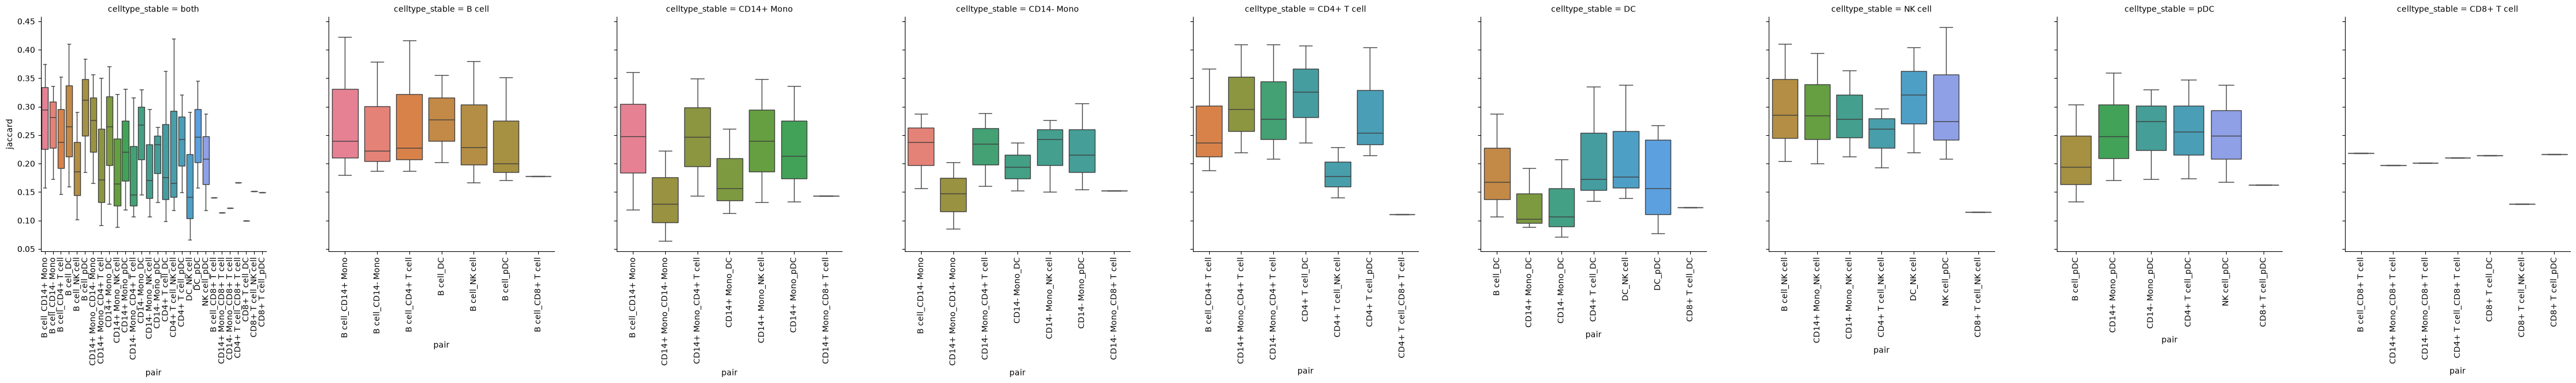

In [14]:
import seaborn as sns
g = sns.catplot(
    data=mycomparisons.reset_index(drop=True),
    x='pair',
    y='jaccard',
    col = 'celltype_stable',
    kind='box',
    hue = 'pair',
    sharex = False)
g.set_xticklabels(rotation=90, horizontalalignment='center')

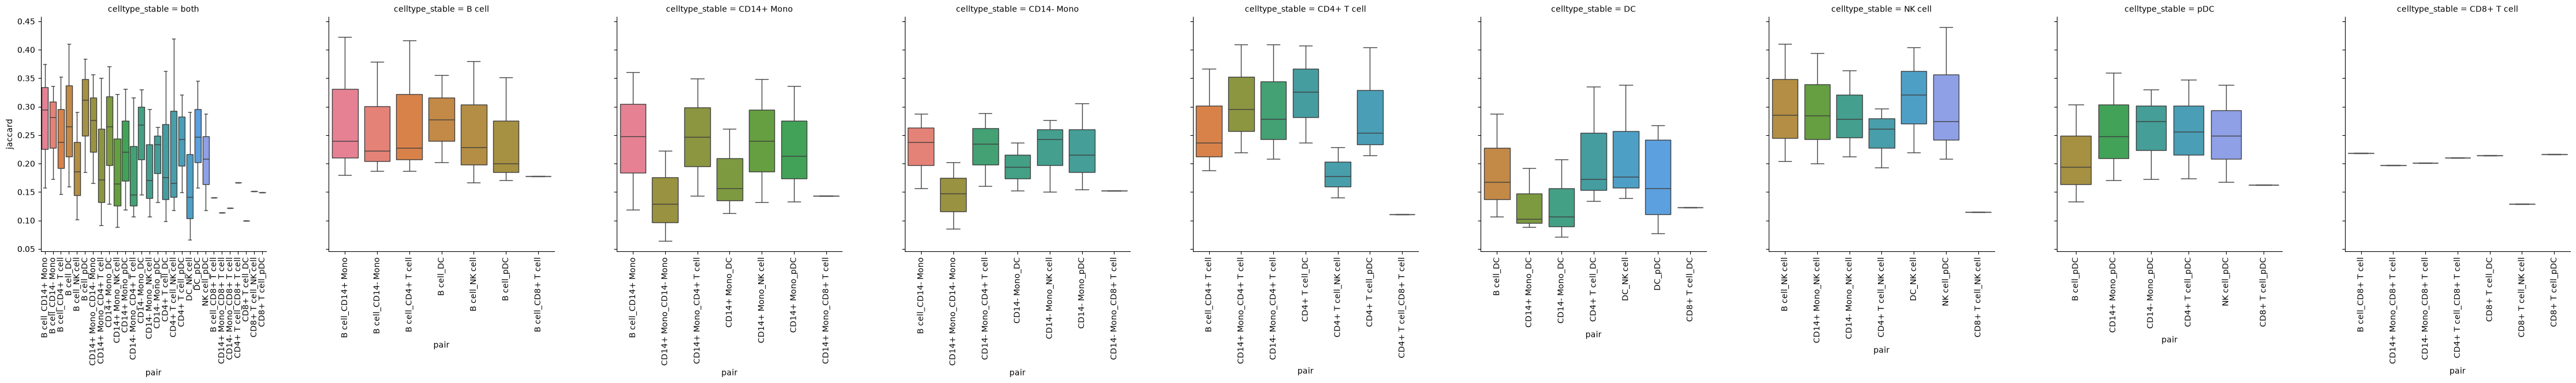

In [16]:
import seaborn as sns
g = sns.catplot(
    data=mycomparisons.reset_index(drop=True),
    x='pair',
    y='jaccard',
    col = 'celltype_stable',
    kind='box',
    hue = 'pair',
    sharex = False)
g.set_xticklabels(rotation=90, horizontalalignment='center')

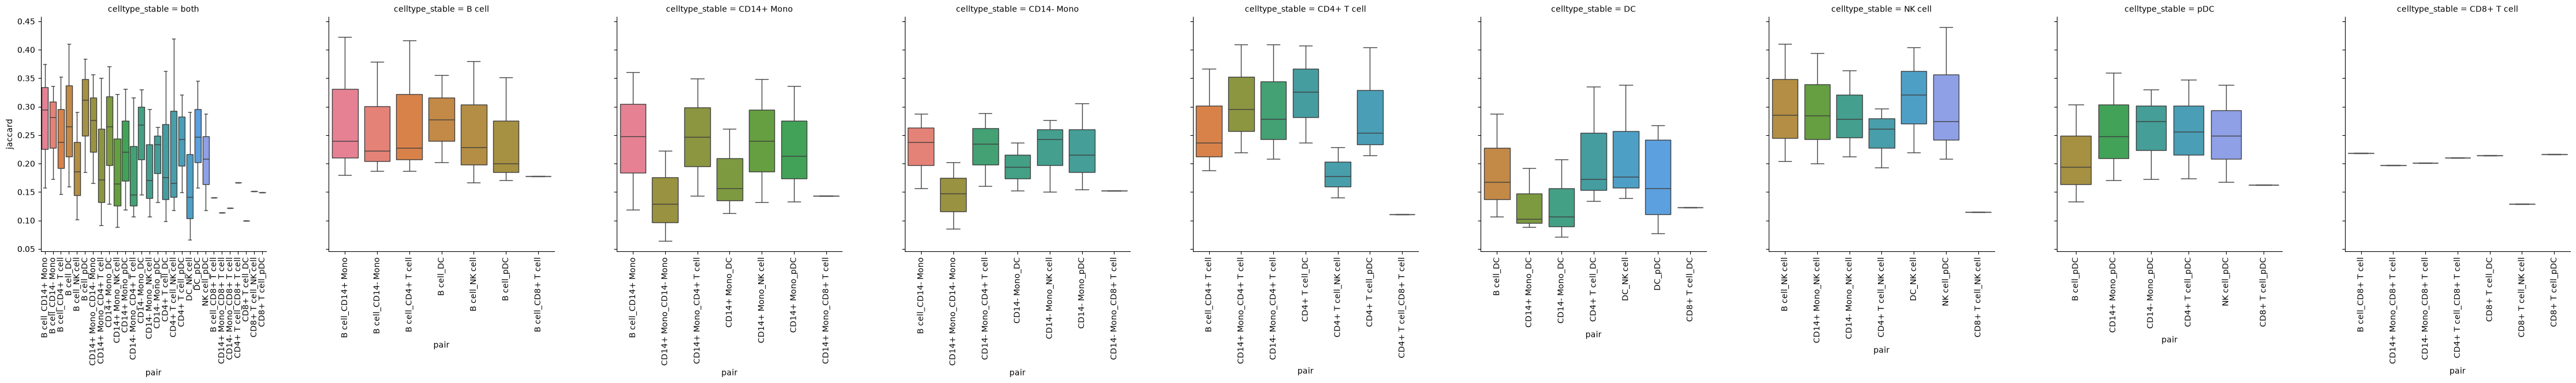

In [17]:
import seaborn as sns
g = sns.catplot(
    data=mycomparisons.reset_index(drop=True),
    x='pair',
    y='jaccard',
    col = 'celltype_stable',
    kind='box',
    hue = 'pair',
    sharex = False)
g.set_xticklabels(rotation=90, horizontalalignment='center')

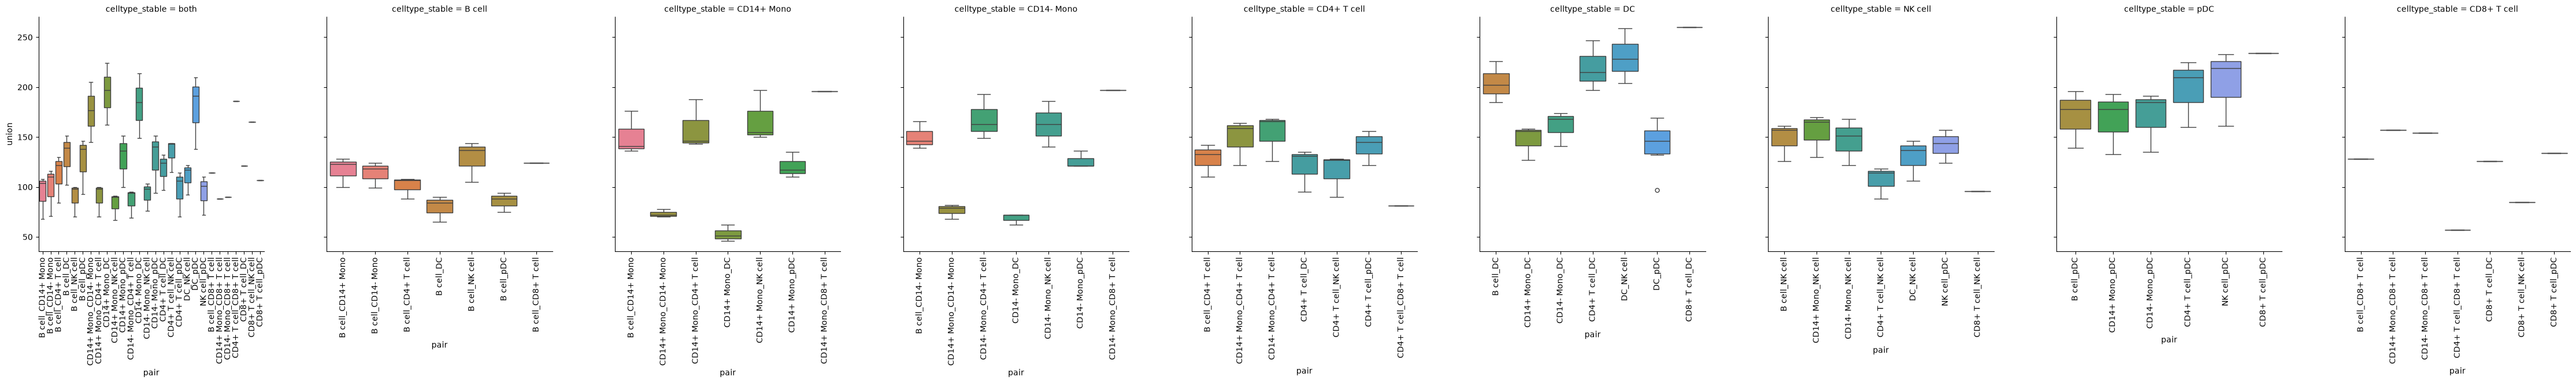

In [18]:
g = sns.catplot(
    data=mycomparisons.reset_index(drop=True),
    x='pair',
    y='union',
    col = 'celltype_stable',
    kind='box',
    hue = 'pair',
    sharex = False)
g.set_xticklabels(rotation=90, horizontalalignment='center')

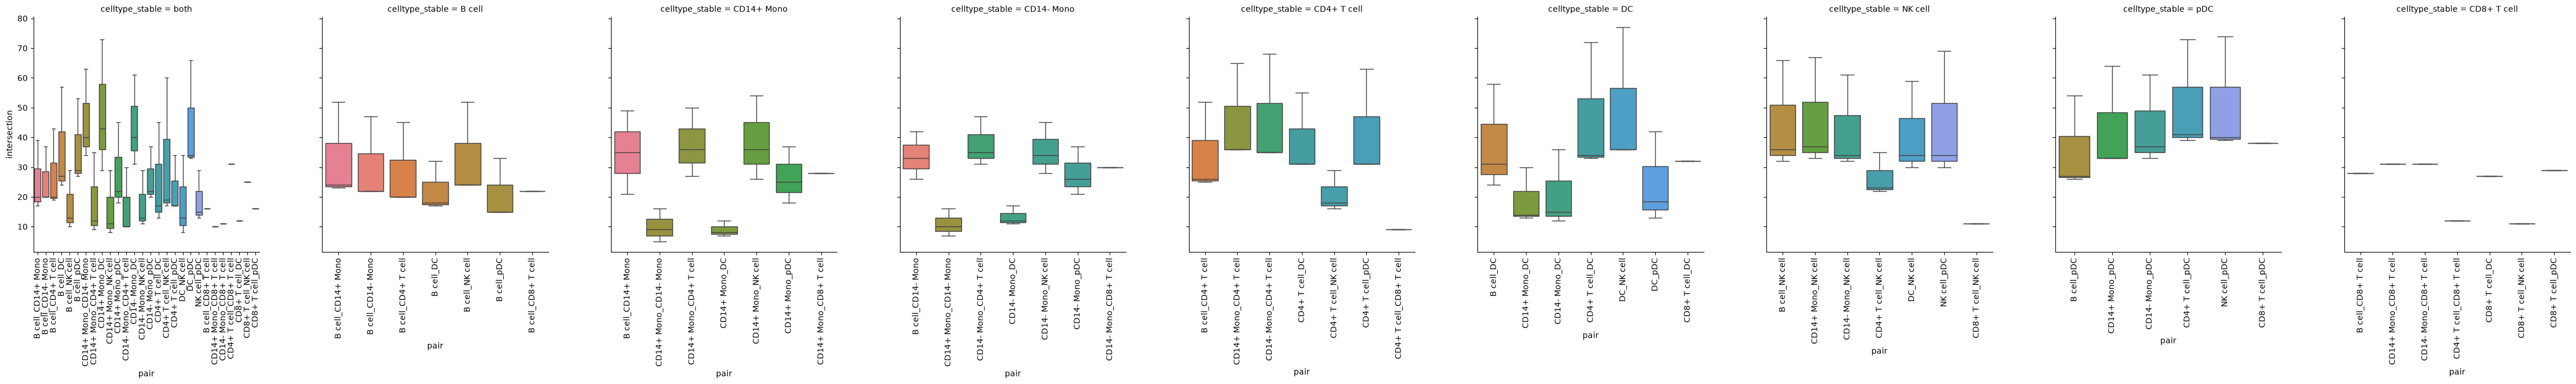

In [19]:
g = sns.catplot(
    data=mycomparisons.reset_index(drop=True),
    x='pair',
    y='intersection',
    col = 'celltype_stable',
    kind='box',
    hue = 'pair',
    sharex = False)
g.set_xticklabels(rotation=90, horizontalalignment='center')